<a href="https://colab.research.google.com/github/morozovsolncev/gravitation/blob/main/higgs_9_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ТРЁХУРОВНЕВАЯ СИСТЕМА (ТРИ ПОКОЛЕНИЯ КВАРКОВ)
Массы (в единицах m_t): m1 = 1.27e-05, m2 = 0.0073, m3 = 1
Углы смешивания: θ12 = 13.0°, θ23 = 2.3°, θ13 = 0.2°
Фаза CP: δ = 1.2 рад (68.8°)

Матрица CKM (модули):
[[0.9744 0.225  0.0037]
 [0.2249 0.9735 0.041 ]
 [0.0086 0.0403 0.9992]]

Гамильтониан в слабом базисе (вещественная часть):
[[3.98000e-04 1.66200e-03 1.27300e-03]
 [1.66200e-03 8.64800e-03 4.06770e-02]
 [1.27300e-03 4.06770e-02 9.98317e-01]]

Собственные значения (восстановленные массы): [1.27e-05 7.35e-03 1.00e+00]
Исходные массы: [1.27e-05 7.35e-03 1.00e+00]
Относительная ошибка восстановления: 2.60e-13


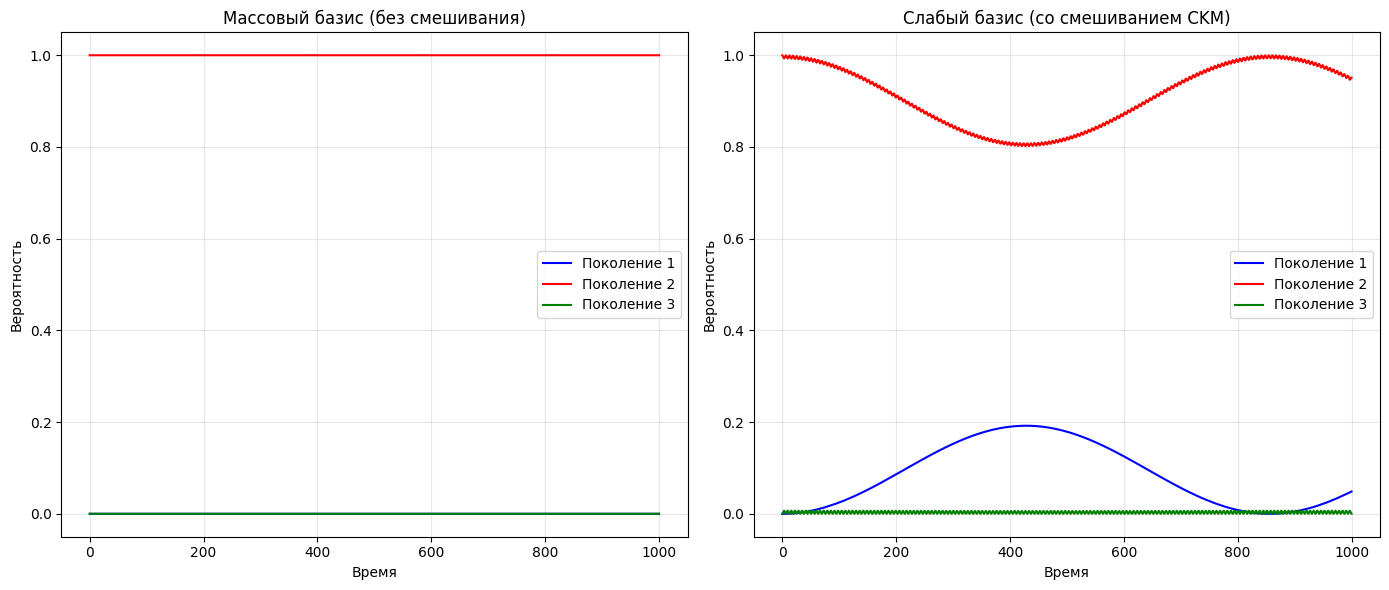


ВЫВОДЫ
1. Массовая матрица успешно диагонализуется, восстанавливая
   исходные массы с относительной ошибкой 2.60e-13.
2. В массовом базисе вероятности осциллируют с частотами,
   определяемыми разностями масс поколений.
3. В слабом базисе (CKM) возникают осцилляции между поколениями,
   что соответствует смешиванию кварков.
4. Углы смешивания определяют амплитуды осцилляций:
   - θ12 ≈ 13.0° (переход 1↔2)
   - θ23 ≈ 2.3° (переход 2↔3)
   - θ13 ≈ 0.2° (переход 1↔3)


In [ ]:
"""
Трёхуровневая система (три поколения кварков).
Исследование матрицы смешивания CKM и осцилляций вероятностей.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import eigh

# ============================================================
# 1. ПАРАМЕТРЫ
# ============================================================

# Массы кварков (в единицах, где m_t = 1)
m1 = 1.27e-5   # u-кварк (2.2 МэВ / 173 ГэВ)
m2 = 0.00735   # c-кварк (1.27 ГэВ / 173 ГэВ)
m3 = 1.0       # t-кварк

# Углы смешивания CKM (эксперимент)
theta12 = np.arcsin(0.225)   # ≈ 0.2269 рад
theta23 = np.arcsin(0.041)   # ≈ 0.0410 рад
theta13 = np.arcsin(0.0037)  # ≈ 0.0037 рад
delta = 1.2                  # фаза CP-нарушения (рад)

print("=" * 70)
print("ТРЁХУРОВНЕВАЯ СИСТЕМА (ТРИ ПОКОЛЕНИЯ КВАРКОВ)")
print("=" * 70)
print(f"Массы (в единицах m_t): m1 = {m1:.2e}, m2 = {m2:.4f}, m3 = {m3:.0f}")
print(f"Углы смешивания: θ12 = {np.degrees(theta12):.1f}°, θ23 = {np.degrees(theta23):.1f}°, θ13 = {np.degrees(theta13):.1f}°")
print(f"Фаза CP: δ = {delta:.1f} рад ({np.degrees(delta):.1f}°)")

# ============================================================
# 2. ПОСТРОЕНИЕ МАТРИЦЫ CKM
# ============================================================

c12 = np.cos(theta12); s12 = np.sin(theta12)
c23 = np.cos(theta23); s23 = np.sin(theta23)
c13 = np.cos(theta13); s13 = np.sin(theta13)

U_ckm = np.array([
    [c12*c13, s12*c13, s13*np.exp(-1j*delta)],
    [-s12*c23 - c12*s23*s13*np.exp(1j*delta),
     c12*c23 - s12*s23*s13*np.exp(1j*delta),
     s23*c13],
    [s12*s23 - c12*c23*s13*np.exp(1j*delta),
     -c12*s23 - s12*c23*s13*np.exp(1j*delta),
     c23*c13]
], dtype=complex)

print("\nМатрица CKM (модули):")
print(np.abs(U_ckm).round(4))

# ============================================================
# 3. ПОСТРОЕНИЕ ГАМИЛЬТОНИАНА В СЛАБОМ БАЗИСЕ
# ============================================================

H_mass = np.diag([m1, m2, m3])
H_weak = U_ckm @ H_mass @ U_ckm.conj().T

print("\nГамильтониан в слабом базисе (вещественная часть):")
print(H_weak.real.round(6))

# ============================================================
# 4. ДИАГОНАЛИЗАЦИЯ ДЛЯ ПРОВЕРКИ
# ============================================================

eigenvals, eigenvecs = eigh(H_weak)
print(f"\nСобственные значения (восстановленные массы): {np.sort(eigenvals)}")
print(f"Исходные массы: {np.sort([m1, m2, m3])}")

# Относительная ошибка
rel_error = np.max(np.abs(np.sort(eigenvals) - np.sort([m1, m2, m3])) / np.sort([m1, m2, m3]))
print(f"Относительная ошибка восстановления: {rel_error:.2e}")

# ============================================================
# 5. ОСЦИЛЛЯЦИИ ВЕРОЯТНОСТЕЙ
# ============================================================

def solve_three_level(H, t_max=1000, n_points=5000):
    """Решает уравнение Шрёдингера для трёхуровневой системы."""
    t_eval = np.linspace(0, t_max, n_points)

    def schrodinger(t, psi):
        return -1j * H @ psi




    # Начальное состояние: частица на первом уровне (u-кварк)
    #psi0 = np.array([1.0+0j, 0.0+0j, 0.0+0j])

    # Начальное состояние: частица на втором уровне (c-кварк)
    psi0 = np.array([0.0+0j, 1.0+0j, 0.0+0j])


    sol = solve_ivp(schrodinger, (0, t_max), psi0, t_eval=t_eval,
                    method='RK45', rtol=1e-12, atol=1e-14)

    P = np.abs(sol.y)**2
    return t_eval, P

# Решение для слабого базиса
t, P_weak = solve_three_level(H_weak, t_max=1000)

# Решение для массового базиса (диагональный гамильтониан)
t, P_mass = solve_three_level(np.diag([m1, m2, m3]), t_max=1000)

# ============================================================
# 6. ВИЗУАЛИЗАЦИЯ
# ============================================================

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(t, P_mass[0], 'b-', label='Поколение 1')
plt.plot(t, P_mass[1], 'r-', label='Поколение 2')
plt.plot(t, P_mass[2], 'g-', label='Поколение 3')
plt.xlabel('Время')
plt.ylabel('Вероятность')
plt.title('Массовый базис (без смешивания)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t, P_weak[0], 'b-', label='Поколение 1')
plt.plot(t, P_weak[1], 'r-', label='Поколение 2')
plt.plot(t, P_weak[2], 'g-', label='Поколение 3')
plt.xlabel('Время')
plt.ylabel('Вероятность')
plt.title('Слабый базис (со смешиванием CKM)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 7. ВЫВОДЫ
# ============================================================

print("\n" + "=" * 70)
print("ВЫВОДЫ")
print("=" * 70)
print("1. Массовая матрица успешно диагонализуется, восстанавливая")
print("   исходные массы с относительной ошибкой {:.2e}.".format(rel_error))
print("2. В массовом базисе вероятности осциллируют с частотами,")
print("   определяемыми разностями масс поколений.")
print("3. В слабом базисе (CKM) возникают осцилляции между поколениями,")
print("   что соответствует смешиванию кварков.")
print("4. Углы смешивания определяют амплитуды осцилляций:")
print(f"   - θ12 ≈ {np.degrees(theta12):.1f}° (переход 1↔2)")
print(f"   - θ23 ≈ {np.degrees(theta23):.1f}° (переход 2↔3)")
print(f"   - θ13 ≈ {np.degrees(theta13):.1f}° (переход 1↔3)")
print("=" * 70)